# RESULTS — Multi-session pipeline

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.stats import wilcoxon
from pynwb import NWBHDF5IO
import ipywidgets as widgets
from IPython.display import display

# ── Paramètres globaux ──────────────────────────────────────────────────────
THIS_AREA     = 'wS1'
Bin_size      = 0.01
AP_Bin_Res    = 1.0 / Bin_size
pre_bins      = 50
post_bins     = 100
amps_stim     = [1, 2, 3, 4]
tol_post      = 0.05
refractory_s  = 0.2
lick_window_s = 1.0
N_PCT         = 200
pct_axis      = np.linspace(1, 99.9, N_PCT)   # full range: low thr → very high thr
time_axis     = (np.arange(pre_bins + post_bins + 1) - pre_bins) * Bin_size
colors_amp    = {1: 'gold', 2: 'orange', 3: 'tomato', 4: 'red'}

std = lambda arr, axis=0: np.std(arr, axis=axis, ddof=1)  # SD across sessions
print('Imports OK')

Imports OK


In [7]:
import glob, os

# ── Scan automatique de data/valid/WR+/ et data/valid/WR-/ ─────────────────
VALID_BASE    = 'data/valid'
GROUPS        = ['WR+', 'WR-']

SESSION_PATHS = []
for _grp in GROUPS:
    _grp_dir = os.path.join(VALID_BASE, _grp)
    SESSION_PATHS.extend(sorted(glob.glob(os.path.join(_grp_dir, '*.nwb'))))

print(f'{len(SESSION_PATHS)} session(s) trouvee(s) dans {VALID_BASE}/ :')
for p in SESSION_PATHS:
    grp = p.split('/')[-2]
    print(f'  [{grp}]  {os.path.basename(p)}')


26 session(s) trouvee(s) dans data/valid/ :
  [WR+]  AO026_20181122_180943.nwb
  [WR+]  AO026_20181123_110337.nwb
  [WR+]  AO027_20181101_134512.nwb
  [WR+]  AO028_20181102_110339.nwb
  [WR+]  AO028_20181103_83222.nwb
  [WR+]  AO036_20190507_183647.nwb
  [WR+]  AO039_20190626_160524.nwb
  [WR+]  AO039_20190627_151857.nwb
  [WR+]  AO040_20190708_124008.nwb
  [WR+]  AO040_20190709_102521.nwb
  [WR+]  AO049_20191009_160435.nwb
  [WR+]  AO050_20191007_195438.nwb
  [WR+]  AO051_20191004_182709.nwb
  [WR+]  AO065_20201023_100155.nwb
  [WR+]  AO066_20201023_180037.nwb
  [WR+]  AO067_20201022_190740.nwb
  [WR+]  AO074_20201222_164350.nwb
  [WR+]  AO075_20201223_134131.nwb
  [WR+]  AO076_20201222_212759.nwb
  [WR+]  AO077_20201223_91923.nwb
  [WR+]  AO078_20201217_213650.nwb
  [WR+]  AO079_20201214_203254.nwb
  [WR+]  MH031_20250509_102210.nwb
  [WR-]  AO081_20210505_192239.nwb
  [WR-]  AO082_20210519_183538.nwb
  [WR-]  AO082_20210521_164409.nwb


In [8]:
# ── Helpers ────────────────────────────────────────────────────────────────

def event_triggered_mean(M, event_times, res, pre=50, post=100):
    W   = pre + post + 1
    acc = np.zeros((M.shape[0], W), dtype=np.float32)
    n   = 0
    for ev in event_times:
        pt = int(np.round(ev * res))
        if pt - pre < 0 or pt + post >= M.shape[1]:
            continue
        acc += M[:, pt - pre: pt + post + 1]
        n   += 1
    return acc / max(n, 1), n

def detect_peaks_fn(score, t, thr, refrac, bin_s, t0, t1):
    mask = (t >= t0) & (t <= t1) & (score > thr)
    idx  = np.where(mask)[0]
    if idx.size == 0:
        return np.array([], dtype=float)
    cuts   = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, cuts)
    peaks  = np.array([g[np.argmax(score[g])] for g in groups], dtype=int)
    min_b  = int(np.round(refrac / bin_s))
    keep   = [peaks[0]]
    for p in peaks[1:]:
        if p - keep[-1] >= min_b:  keep.append(p)
        elif score[p] > score[keep[-1]]: keep[-1] = p
    return t[np.array(keep, dtype=int)]

print('Helpers OK')

Helpers OK


In [9]:
# ── Pipeline par session ────────────────────────────────────────────────────

def run_session(path, target_area=None):
    print(f"\n{'='*60}\nSESSION : {path}")
    _group = path.split('/')[-2]  # WR+ or WR-
    _area  = target_area if target_area is not None else THIS_AREA

    # Normalise _area : peut etre une string ou un tuple (ex: ('SSp-bfd-C2', 'SSp-bfd-C3'))
    if isinstance(_area, (list, tuple)):
        _area_list = list(_area)
        prefix     = _area_list[0].rsplit('-', 1)[0]           # 'SSp-bfd'
        suffixes   = [a.rsplit('-', 1)[-1] for a in _area_list]  # ['C2', 'C3']
        _area_str  = prefix + '-' + '+'.join(suffixes)         # 'SSp-bfd-C2+C3'
    else:
        _area_list = [_area]
        _area_str  = str(_area)

    # 1. Chargement + filtrage wS1 ─────────────────────────────────────────
    with NWBHDF5IO(path, 'r') as io:
        nwb = io.read()
        tr  = nwb.trials.to_dataframe().copy()
        # Detection colonne aire (robuste aux differents formats NWB)
        units_df_tmp = nwb.units.to_dataframe()
        _area_col = next((c for c in ('Target_area', 'ccf_parent_acronym', 'brain_area', 'location')
                          if c in units_df_tmp.columns), None)
        if _area_col is None:
            print('  [!] Aucune colonne d\'aire trouvee — session ignoree'); return None
        raw_areas = units_df_tmp[_area_col].values
        areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else str(a) for a in raw_areas])
        mask  = np.isin(areas, _area_list)
        spike_times = [np.asarray(nwb.units['spike_times'][i]) for i in np.where(mask)[0]]

        try:
            beh       = nwb.processing['behavior']
            piezo_obj = beh['BehavioralTimeSeries']['PiezoLickSignal']
            piezo_data = np.array(piezo_obj.data[:], dtype=np.float32)
            piezo_ts   = np.array(piezo_obj.timestamps[:])
            confirmed_lick_ts = np.array(beh['BehavioralEvents']['jaw_dlc_licks'].timestamps[:])
            has_piezo  = True
        except Exception:
            has_piezo  = False
            print('  [!] Pas de piezo')

        # EngagedTrials cutoff — trim session to engaged period only
        try:
            et_obj  = nwb.processing['behavior']['BehavioralEvents']['EngagedTrials']
            et_ts   = np.array(et_obj.timestamps[:])
            et_data = np.array(et_obj.data[:])
            engaged_mask = (et_data == 1)
            t_max = float(et_ts[engaged_mask].max()) if engaged_mask.any() else np.inf
        except Exception:
            t_max = np.inf

    # ── Apply engagement cutoff ───────────────────────────────────────────
    if t_max < np.inf:
        print(f'  [EngagedTrials] trimming at t={t_max:.1f}s  (full session: {float(tr["stop_time"].max()):.1f}s)')
        tr          = tr[tr['start_time'] < t_max].copy()
        spike_times = [st[st < t_max] for st in spike_times]
        if has_piezo:
            pm         = piezo_ts < t_max
            piezo_data = piezo_data[pm]
            piezo_ts   = piezo_ts[pm]

    print(f'  Units [{_area_str}] : {len(spike_times)}')
    if len(spike_times) == 0:
        return None

    # 2. AP_Bin_Matrx ──────────────────────────────────────────────────────
    t0_s   = float(tr['start_time'].min())
    t1_s   = float(tr['stop_time'].max())
    n_bins = int(np.round(t1_s * AP_Bin_Res))
    edges  = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)
    AP_Bin = np.zeros((len(spike_times), n_bins), dtype=np.float32)
    for k, st in enumerate(spike_times):
        counts, _ = np.histogram(st, bins=edges)
        AP_Bin[k] = counts

    # 3. PSTH stim par amp + catch ─────────────────────────────────────────
    _is_mh = os.path.basename(path).startswith('MH')
    if _is_mh:
        # Fichiers MH : amplitude continue, une seule condition stim -> mappee sur amp 4
        mh_sel      = tr['whisker_stim'].astype(bool) & tr['whisker_stim_time'].notna()
        Stim_by_amp = {a: np.array([]) for a in amps_stim}
        Stim_by_amp[4] = np.sort(tr.loc[mh_sel, 'whisker_stim_time'].to_numpy())
    else:
        stim_sel    = tr['whisker_stim_time'].notna() & tr['whisker_stim_amplitude'].isin(amps_stim)
        Stim_by_amp = {
            a: np.sort(tr.loc[stim_sel & (tr['whisker_stim_amplitude'] == a), 'whisker_stim_time'].to_numpy())
            for a in amps_stim
        }
    if 'no_stim' in tr.columns and 'no_stim_time' in tr.columns:
        catch_sel   = tr['no_stim'].astype(bool) & tr['no_stim_time'].notna()
        Catch_times = np.sort(tr.loc[catch_sel, 'no_stim_time'].to_numpy())
    else:
        Catch_times = np.array([])  # WR- sessions have no catch trials

    CATCH_M, _ = event_triggered_mean(AP_Bin, Catch_times, AP_Bin_Res, pre_bins, post_bins)
    STM_by_amp = {}
    for a in amps_stim:
        STM_by_amp[a], _ = event_triggered_mean(AP_Bin, Stim_by_amp[a], AP_Bin_Res, pre_bins, post_bins)

    psth_stim  = {a: STM_by_amp[a].mean(axis=0) / Bin_size for a in amps_stim}
    psth_catch = CATCH_M.mean(axis=0) / Bin_size

    # 4. Coding Direction (amp4) ───────────────────────────────────────────
    CD = STM_by_amp[4][:, 50:55].mean(axis=1) - CATCH_M[:, 50:55].mean(axis=1)
    CD = CD / (np.linalg.norm(CD) + 1e-12)
    score = CD @ AP_Bin
    t_sig = np.arange(len(score)) * Bin_size

    # 7. Lick detection (piezo) ────────────────────────────────────────────
    if has_piezo:
        piezo_rate = 1.0 / np.median(np.diff(piezo_ts))
        piezo_env  = gaussian_filter1d(np.abs(piezo_data), sigma=int(0.01 * piezo_rate))
        # Noise-based threshold: median + 5*MAD of the envelope
        median_env = np.median(piezo_env)
        mad_env    = np.median(np.abs(piezo_env - median_env))
        thr_piezo  = median_env + 15.0 * mad_env
        min_dist   = int(0.15 * piezo_rate)
        peak_idx, _ = find_peaks(piezo_env, height=thr_piezo, distance=min_dist)
        all_lick_times = piezo_ts[peak_idx]
        print(f'  Licks : {len(all_lick_times)}')
    else:
        all_lick_times = np.array([])

    # 5. TP / FP curves ────────────────────────────────────────────────────
    in_range       = (t_sig >= t0_s) & (t_sig <= t1_s)
    score_in       = score[in_range]
    ths_pct        = np.percentile(score_in, pct_axis)
    # Extend threshold to actual score max (99.9th percentile stops before peaks)
    if score_in.max() > ths_pct[-1]:
        ths_ext = np.linspace(ths_pct[-1], score_in.max(), 30)[1:]
        ths = np.concatenate([ths_pct, ths_ext])
    else:
        ths = ths_pct
    all_stim_times = np.sort(np.concatenate([Stim_by_amp[a] for a in amps_stim]))
    # All trial events (stim + catch) — used for ITI filtering
    all_events     = np.sort(np.concatenate([all_stim_times, Catch_times]))

    tp_c, fp_c, fp_catch_c, lick_after_det_c = {a: [] for a in amps_stim}, [], [], []
    for thr in ths:
        det   = detect_peaks_fn(score, t_sig, thr, refractory_s, Bin_size, t0_s, t1_s)
        n_det = max(len(det), 1)
        in_win = np.zeros(len(det), dtype=bool)
        for st in all_stim_times:
            in_win |= (det >= st) & (det <= st + tol_post)
        fp_c.append(np.sum(~in_win) / n_det)
        fp_catch_c.append(sum(np.any((det >= st) & (det <= st + tol_post)) for st in Catch_times)
                          / max(len(Catch_times), 1))
        if has_piezo:
            det_iti = np.array([d for d in det
                                if not np.any((d >= all_events) & (d <= all_events + 1.0))])
            if len(det_iti) > 0:
                lick_after_det_c.append(
                    sum(np.any((all_lick_times >= d) & (all_lick_times <= d + lick_window_s))
                        for d in det_iti) / len(det_iti)
                )
            else:
                lick_after_det_c.append(np.nan)
        else:
            lick_after_det_c.append(np.nan)
        for a in amps_stim:
            tp_c[a].append(sum(np.any((det >= st) & (det <= st + tol_post)) for st in Stim_by_amp[a])
                           / max(len(Stim_by_amp[a]), 1))

    tp_c = {a: np.array(tp_c[a]) for a in amps_stim}
    fp_c, fp_catch_c = np.array(fp_c), np.array(fp_catch_c)
    lick_after_det_c = np.array(lick_after_det_c)

    # 6. Meilleur threshold ────────────────────────────────────────────────
    youden   = tp_c[4] - fp_c
    mask_50  = tp_c[4] >= 0.5
    mask_any = tp_c[4] > 0
    if mask_50.any():
        best_i = int(np.argmax(np.where(mask_50,  youden, -np.inf)))
    elif mask_any.any():
        best_i = int(np.argmax(np.where(mask_any, youden, -np.inf)))
    else:
        best_i = 0
    best_thr = ths[best_i]
    det_best = detect_peaks_fn(score, t_sig, best_thr, refractory_s, Bin_size, t0_s, t1_s)
    print(f'  Best thr={best_thr:.4f}  TP4={tp_c[4][best_i]:.2f}  FP={fp_c[best_i]:.2f}')

    # 8. Matrice stim/burst x lick/no lick ────────────────────────────────
    stim_results = {}
    for a in amps_stim:
        tl, tnl, ml, mnl = 0, 0, 0, 0
        for st in Stim_by_amp[a]:
            det  = np.any((det_best >= st) & (det_best <= st + tol_post))
            lick = np.any((all_lick_times >= st) & (all_lick_times <= st + lick_window_s))
            if   det  and lick:      tl  += 1
            elif det  and not lick:  tnl += 1
            elif not det and lick:   ml  += 1
            else:                    mnl += 1
        stim_results[a] = (tl, tnl, ml, mnl)

    burst_times = np.array([dt for dt in det_best
                             if not np.any((dt >= all_events) & (dt <= all_events + 1.0))])
    burst_lick   = sum(np.any((all_lick_times >= dt) & (all_lick_times <= dt + lick_window_s))
                       for dt in burst_times)
    burst_nolick = len(burst_times) - burst_lick

    # 9. Chance level ──────────────────────────────────────────────────────
    n_ctrl = max(len(burst_times), 1)
    rng = np.random.default_rng(0)
    ctrl, n_tries = [], 0
    while len(ctrl) < n_ctrl and n_tries < 500000:
        t = rng.uniform(t0_s + 1.0, t1_s - lick_window_s)
        near_trial  = np.any((t >= all_events) & (t <= all_events + 1.0))
        near_detect = np.any((det_best >= t - 1.0) & (det_best <= t + lick_window_s))
        if not near_trial and not near_detect:
            ctrl.append(t)
        n_tries += 1
    ctrl = np.array(ctrl)
    chance_lick = np.mean([np.any((all_lick_times >= t) & (all_lick_times <= t + lick_window_s))
                            for t in ctrl]) if len(ctrl) > 0 else np.nan
    print(f'  Bursts (ITI)={len(burst_times)}  Ctrl (same N, ITI)={len(ctrl)}')

    # 10. Bouts de lick par categorie ──────────────────────────────────────
    bout_durs = {c: [] for c in ['stim4','stim3','stim2','stim1','burst','none']}
    if len(all_lick_times) > 1:
        lts   = np.sort(all_lick_times)
        cuts  = np.where(np.diff(lts) > 1.0)[0] + 1
        bouts = np.split(lts, cuts)
        b_s   = np.array([g[0]  for g in bouts])
        b_e   = np.array([g[-1] for g in bouts])
        for i, tb in enumerate(b_s):
            dur   = b_e[i] - tb
            cands = det_best[(det_best >= tb - lick_window_s) & (det_best < tb)]
            if len(cands) == 0:
                bout_durs['none'].append(dur); continue
            best_amp, has_burst = None, False
            for pk in cands:
                for a in [4, 3, 2, 1]:
                    if np.any((pk >= Stim_by_amp[a]) & (pk <= Stim_by_amp[a] + tol_post)):
                        if best_amp is None or a > best_amp: best_amp = a
                        break
                else:
                    has_burst = True
            if best_amp is not None: bout_durs[f'stim{best_amp}'].append(dur)
            else:                    bout_durs['burst'].append(dur)

    tp4_l, tp4_nl, _, _ = stim_results[4]
    p_stim4 = tp4_l / max(tp4_l + tp4_nl, 1)
    p_burst = burst_lick / max(len(burst_times), 1)
    print(f'  P(lick|stim4 det)={p_stim4:.3f}  P(lick|burst)={p_burst:.3f}  Chance={chance_lick:.3f}')

    return {
        'path'         : path,
        'n_units'      : len(spike_times),
        'psth_stim'    : psth_stim,
        'psth_catch'   : psth_catch,
        'thresholds'   : ths,
        'best_i'       : best_i,
        'tp_curves'    : tp_c,
        'fp_cont'      : fp_c,
        'fp_catch'     : fp_catch_c,
        'stim_results' : stim_results,
        'burst_lick'   : burst_lick,
        'burst_nolick' : burst_nolick,
        'n_burst'      : len(burst_times),
        'chance_lick'  : chance_lick,
        'p_stim4'      : p_stim4,
        'p_burst'      : p_burst,
        'bout_durs'    : bout_durs,
        'group'        : _group,
        'area'         : _area_str,
        'is_mh'        : _is_mh,
        'lick_after_det': lick_after_det_c,
        't_duration'   : t1_s - t0_s,
    }

print('Pipeline OK')


Pipeline OK


In [10]:
# ── Lancement sur toutes les sessions ──────────────────────────────────────
# Pour les fichiers MH* : pool les neurones SSp-bfd-C2 + SSp-bfd-C3 en une seule session
MH_AREA_SYNONYMS = {'SSp-bfd-C2', 'SSp-bfd-C3'}  # C2 et C3 fusionnes, SSp-bfd seul exclu

def _areas_for_path(path):
    """MH* : retourne un tuple unique (C2, C3) pour pooler les deux populations.
    Autres fichiers : [None] (utilise THIS_AREA globalement)."""
    if os.path.basename(path).startswith('MH'):
        try:
            with NWBHDF5IO(path, 'r') as _io:
                units_df = _io.read().units.to_dataframe()
            for col in ('Target_area', 'ccf_parent_acronym', 'brain_area', 'location'):
                if col in units_df.columns:
                    raw   = units_df[col].values
                    areas = [(a.decode() if isinstance(a, (bytes, bytearray)) else str(a)) for a in raw]
                    avail = sorted({a for a in areas if a in MH_AREA_SYNONYMS})
                    # Un seul tuple -> une seule session avec toutes les aires disponibles poolees
                    return [tuple(avail)] if avail else [None]
        except Exception as e:
            print(f'  [!] _areas_for_path({os.path.basename(path)}): {e}')
        return [None]
    return [None]

results = []
# for path in [p for p in SESSION_PATHS if 'AO076_20201222_212759' in p]:  # test 1 session
for path in SESSION_PATHS:
    for area in _areas_for_path(path):
        r = run_session(path, target_area=area)
        if r is not None:
            results.append(r)

N = len(results)
results_wrp       = [r for r in results if r.get('group') == 'WR+']
results_wrm       = [r for r in results if r.get('group') == 'WR-']
results_wrp_piezo = [r for r in results_wrp if not r.get('is_mh', False)]
N_wrp, N_wrm = len(results_wrp), len(results_wrm)

# Label unique : ajoute [aire] si ce n'est pas l'aire par defaut (ex: sessions MH)
def _result_label(r):
    base = r['path'].split('/')[-1]
    if r.get('area') and r['area'] != THIS_AREA:
        base = base.replace('.nwb', f'_{r["area"]}.nwb')
    return f"[{r['group']}] {base}"

label_to_result = {_result_label(r): r for r in results}

print(f'\n{N} session(s) traitee(s) avec succes  ({N_wrp} WR+  /  {N_wrm} WR-)')
for r in results:
    print(f"  [{r['group']}] {_result_label(r).split(']')[-1].strip()}  -  {r['n_units']} units  [{r.get('area', THIS_AREA)}]")



SESSION : data/valid/WR+/AO026_20181122_180943.nwb
  [EngagedTrials] trimming at t=3880.9s  (full session: 3882.9s)
  Units [wS1] : 30
  Licks : 2554
  Best thr=1.5855  TP4=0.94  FP=0.95
  Bursts (ITI)=1165  Ctrl (same N, ITI)=1165
  P(lick|stim4 det)=0.935  P(lick|burst)=0.300  Chance=0.165

SESSION : data/valid/WR+/AO026_20181123_110337.nwb
  [EngagedTrials] trimming at t=4875.9s  (full session: 5643.4s)
  Units [wS1] : 40
  Licks : 774
  Best thr=1.3777  TP4=0.94  FP=0.98
  Bursts (ITI)=6071  Ctrl (same N, ITI)=6071
  P(lick|stim4 det)=0.565  P(lick|burst)=0.053  Chance=0.047

SESSION : data/valid/WR+/AO027_20181101_134512.nwb
  [EngagedTrials] trimming at t=4628.9s  (full session: 5383.6s)
  Units [wS1] : 26
  Licks : 3147
  Best thr=1.6247  TP4=0.78  FP=0.98
  Bursts (ITI)=4416  Ctrl (same N, ITI)=4416
  P(lick|stim4 det)=0.172  P(lick|burst)=0.190  Chance=0.210

SESSION : data/valid/WR+/AO028_20181102_110339.nwb
  [EngagedTrials] trimming at t=6502.8s  (full session: 6504.8s)
  

---
## Plots — Mean ± SD across all sessions

In [11]:
# -- Plot 1 : Mean PSTH by amplitude + catch --
session_names_p1 = ['Mean WR+', 'Mean WR-', 'Mean WR+ vs WR-', 'By n_units'] + [_result_label(r) for r in results]

def plot_psth(session='Mean WR+'):
    if session == 'By n_units':
        from scipy.stats import linregress
        n_units_arr = np.array([r['n_units'] for r in results_wrp])
        t_mask = (time_axis >= 0) & (time_axis <= 0.05)
        fig, ax = plt.subplots(figsize=(9, 5))
        for a in amps_stim:
            peak_per_sess = np.array([r['psth_stim'][a][t_mask].mean() for r in results_wrp])
            valid = ~np.isnan(peak_per_sess)
            ax.scatter(n_units_arr[valid], peak_per_sess[valid], color=colors_amp[a],
                       edgecolor='k', s=70, zorder=5, label=f'Amp {a}', alpha=0.85)
            if valid.sum() > 2:
                sl, inter, r_val, p_val, _ = linregress(n_units_arr[valid], peak_per_sess[valid])
                xf = np.linspace(n_units_arr[valid].min(), n_units_arr[valid].max(), 100)
                ax.plot(xf, sl*xf + inter, color=colors_amp[a], lw=1.8, linestyle='--', alpha=0.7,
                        label=f'  r={r_val:.2f}  p={p_val:.3f}')
        ax.set_xlabel('N wS1 neurons (WR+ only)'); ax.set_ylabel('Mean firing rate 0-50ms (Hz)')
        ax.legend(fontsize=9)
        ax.set_title('Peak PSTH response (0-50ms) vs N wS1 neurons\n(dashed = linear regression)')
        fig.suptitle('By neuron count (WR+ only)', fontweight='bold')
        plt.tight_layout(); plt.show(); return

    fig, ax = plt.subplots(figsize=(10, 4))

    if session in ('Mean WR+', 'Mean WR-'):
        grp_res = results_wrp if session == 'Mean WR+' else results_wrm
        n_g     = len(grp_res)
        lbl     = session.replace('Mean ', '')
        if not grp_res:
            ax.text(0.5, 0.5, f'No {lbl} sessions', ha='center', va='center',
                    transform=ax.transAxes, fontsize=14)
        else:
            catch_arr = np.stack([r['psth_catch'] for r in grp_res])
            m, sd = catch_arr.mean(axis=0), std(catch_arr)
            ax.plot(time_axis, m, color='steelblue', lw=2, label='Catch')
            ax.fill_between(time_axis, m - sd, m + sd, alpha=0.2, color='steelblue')
            for a in amps_stim:
                arr = np.stack([r['psth_stim'][a] for r in grp_res])
                m, sd = arr.mean(axis=0), std(arr)
                ax.plot(time_axis, m, color=colors_amp[a], lw=2, label=f'Amp {a}')
                ax.fill_between(time_axis, m - sd, m + sd, alpha=0.2, color=colors_amp[a])
        ax.set_title(f'Mean PSTH wS1 — {lbl}  ({n_g} sessions, mean +/- SD)')

    elif session == 'Mean WR+ vs WR-':
        # WR+ vs WR- mean PSTH comparison
        for grp_lbl, grp_res, ls in [('WR+', results_wrp, '-'), ('WR-', results_wrm, '--')]:
            if not grp_res: continue
            catch_g = np.stack([r['psth_catch'] for r in grp_res])
            m = catch_g.mean(axis=0)
            ax.plot(time_axis, m, color='steelblue', lw=2, linestyle=ls,
                    label=f'Catch ({grp_lbl})')
            for a in amps_stim:
                arr = np.stack([r['psth_stim'][a] for r in grp_res])
                m = arr.mean(axis=0)
                ax.plot(time_axis, m, color=colors_amp[a], lw=2, linestyle=ls,
                        label=f'Amp {a} ({grp_lbl})')
        ax.set_title(f'Mean PSTH — WR+ (solid, n={N_wrp}) vs WR- (dashed, n={N_wrm})')

    else:
        r = label_to_result[session]
        ax.plot(time_axis, r['psth_catch'], color='steelblue', lw=2, label='Catch')
        _mh = r.get('is_mh', False)
        for a in amps_stim:
            if _mh and a != 4: continue  # amps 1/2/3 vides pour sessions MH
            lbl = 'Stim' if _mh else f'Amp {a}'
            ax.plot(time_axis, r['psth_stim'][a], color=colors_amp[a], lw=2, label=lbl)
        grp = r.get('group', '')
        ax.set_title(f'PSTH — {session}  [{grp}]')

    ax.axvline(0, color='k', linestyle='--', lw=1)
    ax.set_xlabel('Time relative to stim (s)')
    ax.set_ylabel('Firing rate (Hz)')
    ax.legend()
    plt.tight_layout()
    plt.show()

widgets.interact(plot_psth, session=session_names_p1)


interactive(children=(Dropdown(description='session', options=('Mean WR+', 'Mean WR-', 'Mean WR+ vs WR-', 'By …

<function __main__.plot_psth(session='Mean WR+')>

interactive(children=(Dropdown(description='Session:', options=('Mean WR+', 'Mean WR-', 'Mean WR+ vs WR-', '[W…

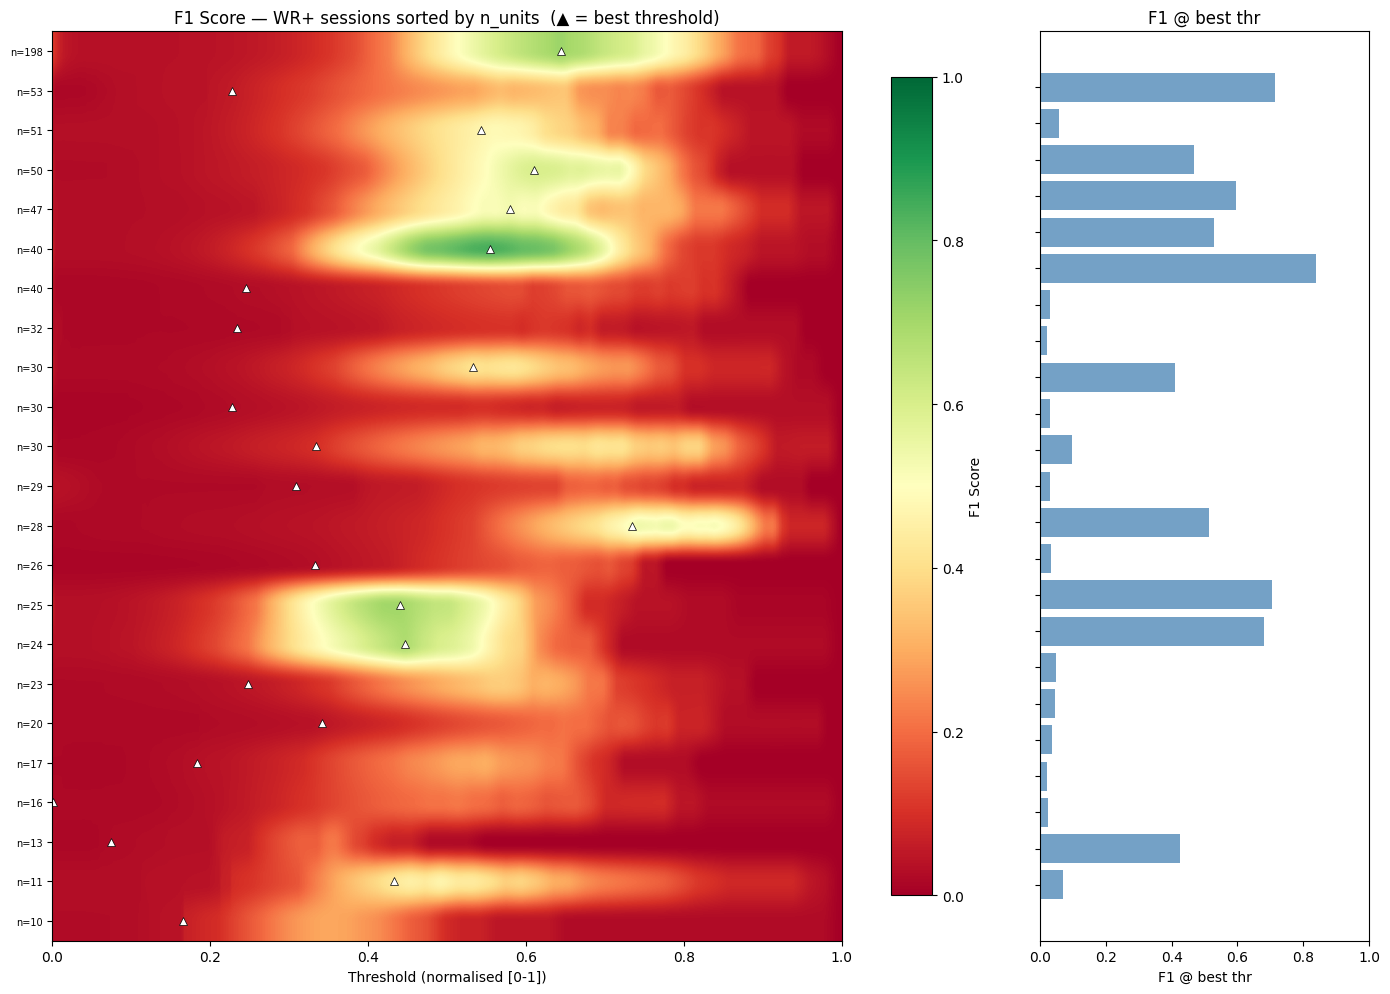

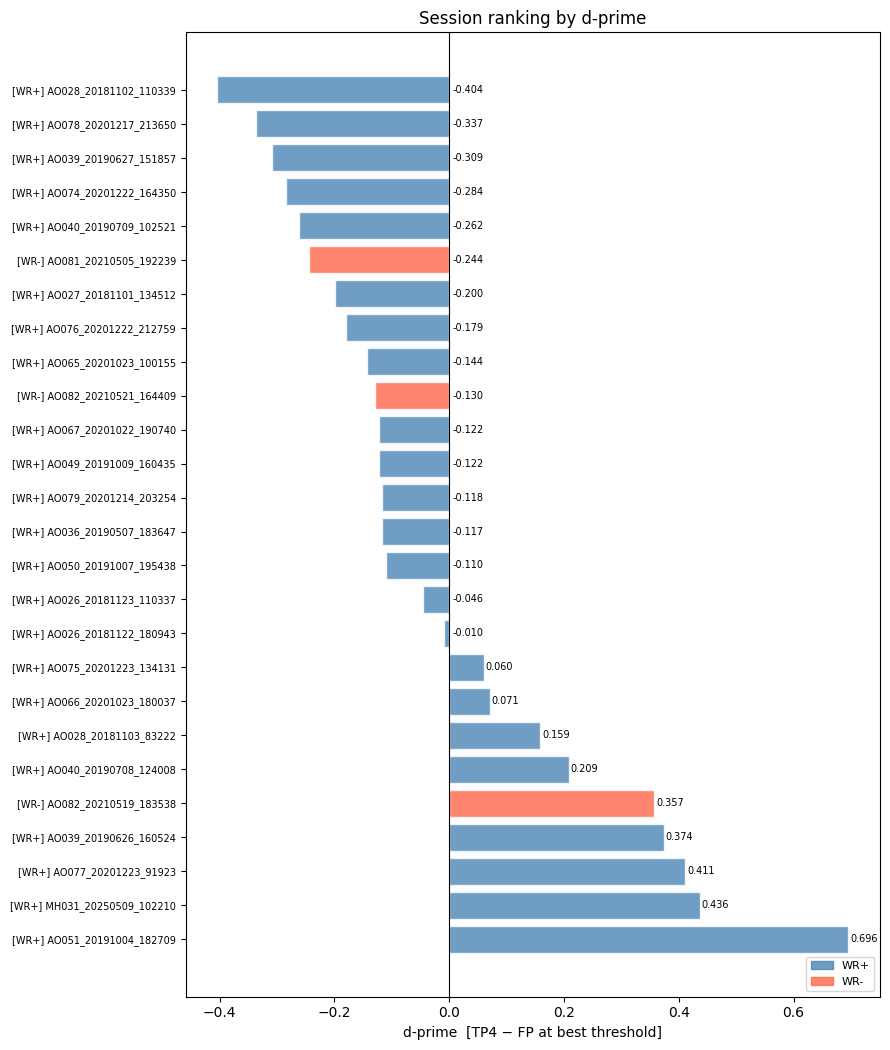

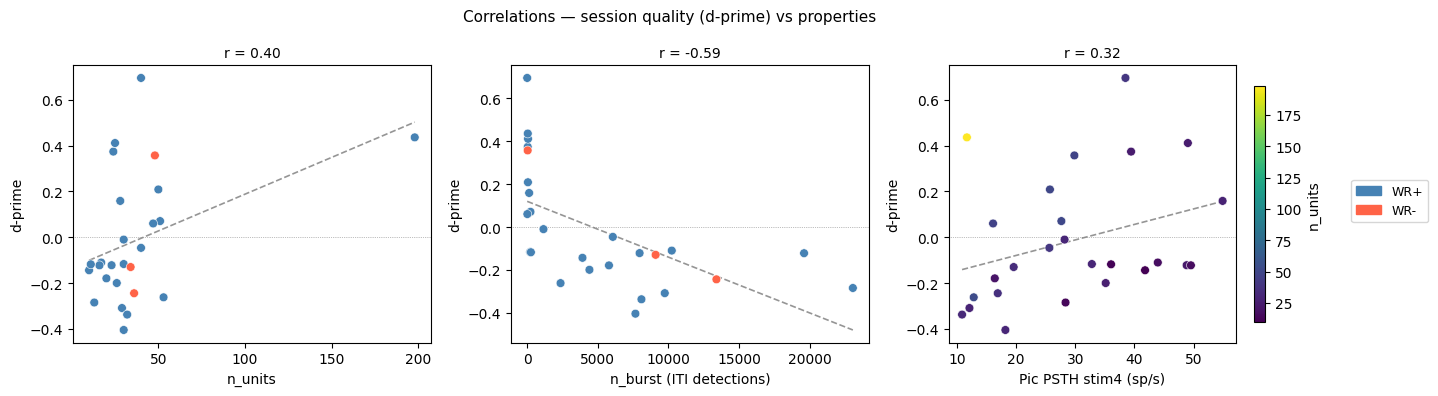

In [12]:
# -- Plot 2 : TP / FP vs Threshold --
session_names_p2 = ['Mean WR+', 'Mean WR-', 'Mean WR+ vs WR-'] + [_result_label(r) for r in results]
X_COMMON = np.linspace(0, 1, 300)

def _interp_norm(r, key, amp=None):
    thr   = r['thresholds']
    thr_n = (thr - thr.min()) / (thr.max() - thr.min() + 1e-12)
    y     = r['tp_curves'][amp] if amp is not None else r[key]
    return np.interp(X_COMMON, thr_n, y)

def _compute_dprime(r):
    # Youden au meilleur threshold : TP4 - FP au point optimal
    return float(r['tp_curves'][4][r['best_i']] - r['fp_cont'][r['best_i']])

def _plot_mean_tpfp(ax, grp_res, lw=2.5, alpha_fill=0.2, ls='-', suffix=''):
    if not grp_res: return
    for a in amps_stim:
        arr = np.stack([_interp_norm(r, None, amp=a) for r in grp_res])
        m, sd_ = arr.mean(0), std(arr)
        ax.plot(X_COMMON, m, color=colors_amp[a], lw=lw, linestyle=ls,
                label=f'TP amp {a}{suffix}')
        ax.fill_between(X_COMMON, m - sd_, m + sd_, alpha=alpha_fill, color=colors_amp[a])
    for label, key, color, style in [('FP cont', 'fp_cont', 'black', '--'),
                                      ('FP catch', 'fp_catch', 'gray', ':')]:
        arr = np.stack([_interp_norm(r, key) for r in grp_res])
        m, sd_ = arr.mean(0), std(arr)
        ax.plot(X_COMMON, m, color=color, lw=lw, linestyle=style,
                label=f'{label}{suffix}')
        ax.fill_between(X_COMMON, m - sd_, m + sd_, alpha=alpha_fill * 0.7, color=color)
    lick_res = [r for r in grp_res if 'lick_after_det' in r and not np.all(np.isnan(r['lick_after_det']))]
    if lick_res:
        arr_l = np.stack([_interp_norm(r, 'lick_after_det') for r in lick_res])
        m_l, sd_l = np.nanmean(arr_l, 0), np.nanstd(arr_l, 0, ddof=1)
        ax.plot(X_COMMON, m_l, color='purple', lw=lw, linestyle='--',
                marker='v', markevery=30, label=f'P(lick|ITI burst){suffix}')
        ax.fill_between(X_COMMON, m_l - sd_l, m_l + sd_l, alpha=alpha_fill * 0.7, color='purple')

def plot_tpfp(session='Mean WR+'):
    fig, ax = plt.subplots(figsize=(9, 5))

    if session in ('Mean WR+', 'Mean WR-'):
        grp_res = results_wrp if session == 'Mean WR+' else results_wrm
        n_g     = len(grp_res)
        lbl     = session.replace('Mean ', '')
        for r in grp_res:
            thr_n = (r['thresholds'] - r['thresholds'].min()) / (r['thresholds'].max() - r['thresholds'].min() + 1e-12)
            for a in amps_stim:
                ax.plot(thr_n, r['tp_curves'][a], color=colors_amp[a], lw=0.6, alpha=0.25)
            ax.plot(thr_n, r['fp_cont'],  color='black', lw=0.6, alpha=0.2, linestyle='--')
            ax.plot(thr_n, r['fp_catch'], color='gray',  lw=0.6, alpha=0.2, linestyle=':')
        _plot_mean_tpfp(ax, grp_res)
        if grp_res:
            best_norms = [(r['thresholds'][r['best_i']] - r['thresholds'].min()) /
                          (r['thresholds'].max() - r['thresholds'].min() + 1e-12) for r in grp_res]
            mean_tp = np.mean([r['tp_curves'][4][r['best_i']] for r in grp_res])
            mean_fp = np.mean([r['fp_cont'][r['best_i']]      for r in grp_res])
            ax.axvline(np.mean(best_norms), color='purple', lw=1.5, linestyle='--',
                       label=f'Best thr  TP4={mean_tp:.2f}  FP={mean_fp:.2f}')
        ax.set_xlabel('Threshold (normalised [0-1] per session)')
        ax.set_title(f'TP / FP vs Threshold — {lbl}  ({n_g} sessions, mean ± SD)')

    elif session == 'Mean WR+ vs WR-':
        _plot_mean_tpfp(ax, results_wrp, ls='-',  suffix=' WR+')
        _plot_mean_tpfp(ax, results_wrm, ls='--', suffix=' WR-', alpha_fill=0.1)
        ax.set_xlabel('Threshold (normalised [0-1] per session)')
        ax.set_title(f'TP / FP — WR+ (solid, n={N_wrp}) vs WR- (dashed, n={N_wrm})')

    else:
        r   = label_to_result[session]
        thr = r['thresholds']
        for a in amps_stim:
            ax.plot(thr, r['tp_curves'][a], color=colors_amp[a], lw=2, label=f'TP amp {a}')
        ax.plot(thr, r['fp_cont'],  color='black', lw=2, linestyle='--', label='FP continuous')
        ax.plot(thr, r['fp_catch'], color='gray',  lw=2, linestyle=':',  label='FP catch')
        if 'lick_after_det' in r and not np.all(np.isnan(r['lick_after_det'])):
            ax.plot(thr, r['lick_after_det'], color='purple', lw=2, linestyle='--',
                    marker='v', markevery=max(1, len(thr) // 20),
                    label='P(lick | ITI burst)')
        best_val = thr[r['best_i']]
        tp_b = r['tp_curves'][4][r['best_i']]; fp_b = r['fp_cont'][r['best_i']]
        ax.axvline(best_val, color='purple', lw=1.5, linestyle='--',
                   label=f'Best thr={best_val:.4f}  TP4={tp_b:.2f}  FP={fp_b:.2f}')
        ax.set_xlabel('Threshold (absolute value)')
        ax.set_title(f'TP / FP vs Threshold — {session}')

    ax.set_ylabel('Rate'); ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

widgets.interact(plot_tpfp, session=widgets.Dropdown(options=session_names_p2, description='Session:'))

# ── F1 Score Heatmap (WR+, sessions triées par n_units) ──────────────────────────────
def plot_f1_heatmap():
    wrp_s  = sorted(results_wrp, key=lambda r: r['n_units'])
    n_sess = len(wrp_s)
    F1_mat = np.full((n_sess, len(X_COMMON)), np.nan)
    for i, r in enumerate(wrp_s):
        tp4  = _interp_norm(r, None, amp=4)
        fp   = _interp_norm(r, 'fp_cont')
        prec = np.clip(1.0 - fp, 0, 1)
        rec  = tp4
        denom = prec + rec
        with np.errstate(invalid='ignore', divide='ignore'):
            F1_mat[i] = np.where(denom > 0, 2 * prec * rec / denom, 0.0)

    best_x = [(r['thresholds'][r['best_i']] - r['thresholds'].min()) /
               (r['thresholds'].max() - r['thresholds'].min() + 1e-12) for r in wrp_s]
    n_units_lbls = [r['n_units'] for r in wrp_s]

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.35 * n_sess + 2)),
                              gridspec_kw={'width_ratios': [3, 1]})
    ax = axes[0]
    im = ax.imshow(F1_mat, aspect='auto', origin='lower', cmap='RdYlGn',
                   vmin=0, vmax=1, extent=[0, 1, -0.5, n_sess - 0.5])
    plt.colorbar(im, ax=ax, label='F1 Score', shrink=0.9)
    for i, bx in enumerate(best_x):
        ax.plot(bx, i, '^', color='white', ms=6, markeredgecolor='black', markeredgewidth=0.5)
    ax.set_xlabel('Threshold (normalised [0-1])')
    ax.set_yticks(range(n_sess))
    ax.set_yticklabels([f'n={u}' for u in n_units_lbls], fontsize=7)
    ax.set_title('F1 Score — WR+ sessions sorted by n_units  (▲ = best threshold)')

    ax2 = axes[1]
    f1_at_best = [F1_mat[i, np.argmin(np.abs(X_COMMON - best_x[i]))] for i in range(n_sess)]
    ax2.barh(range(n_sess), f1_at_best, color='steelblue', alpha=0.75)
    ax2.set_yticks(range(n_sess))
    ax2.set_yticklabels([])
    ax2.set_xlabel('F1 @ best thr')
    ax2.set_xlim(0, 1)
    ax2.set_title('F1 @ best thr')
    plt.tight_layout(); plt.show()

plot_f1_heatmap()

# ── Classement sessions par d-prime ────────────────────────────────────────────
def plot_dprime_ranking():
    from matplotlib.patches import Patch
    ranked     = sorted([(r, _compute_dprime(r)) for r in results], key=lambda x: x[1], reverse=True)
    colors_grp = {'WR+': 'steelblue', 'WR-': 'tomato'}
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(ranked) + 1.5)))
    for i, (r, dp) in enumerate(ranked):
        col = colors_grp.get(r.get('group', 'WR+'), 'gray')
        ax.barh(i, dp, color=col, alpha=0.78, edgecolor='white')
        ax.text(max(dp + 0.003, 0.005), i, f'{dp:.3f}', va='center', fontsize=7)
    ax.set_yticks(range(len(ranked)))
    ax.set_yticklabels([f"[{r.get('group','')}] {r['path'].split('/')[-1].replace('.nwb','')}"
                        for r, _ in ranked], fontsize=7)
    ax.axvline(0, color='black', lw=0.8)
    ax.legend(handles=[Patch(color='steelblue', alpha=0.78, label='WR+'),
                        Patch(color='tomato',    alpha=0.78, label='WR-')],
              fontsize=8, loc='lower right')
    ax.set_xlabel('d-prime  [TP4 − FP at best threshold]')
    ax.set_title('Session ranking by d-prime')
    plt.tight_layout(); plt.show()

plot_dprime_ranking()

# ── Corrélations : qualité de session vs propriétés ────────────────────────────
def plot_correlations():
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    from matplotlib.patches import Patch

    dprimes    = np.array([_compute_dprime(r) for r in results])
    n_units_a  = np.array([r['n_units'] for r in results])
    n_burst_a  = np.array([r['n_burst'] for r in results])
    peak_amp_a = np.array([np.max(r['psth_stim'][4]) for r in results])
    cols_grp   = ['steelblue' if r.get('group') == 'WR+' else 'tomato' for r in results]

    # (x, y, xlabel, ylabel, point_colors_or_None, cval_for_colormap_or_None)
    metrics = [
        (n_units_a,  dprimes, 'n_units',                  'd-prime', cols_grp, None),
        (n_burst_a,  dprimes, 'n_burst (ITI detections)', 'd-prime', cols_grp, None),
        (peak_amp_a, dprimes, 'Pic PSTH stim4 (sp/s)',    'd-prime', None,     n_units_a),
    ]

    fig, axes = plt.subplots(1, len(metrics), figsize=(4.5 * len(metrics), 4))
    if len(metrics) == 1: axes = [axes]
    for ax, (x, y, xl, yl, cols, cval) in zip(axes, metrics):
        if cval is not None:
            # Dernier plot : couleur par n_units (colormap)
            norm = mcolors.Normalize(vmin=cval.min(), vmax=cval.max())
            sc   = ax.scatter(x, y, c=cval, cmap='viridis', norm=norm,
                              s=40, edgecolors='white', linewidths=0.4, zorder=3)
            plt.colorbar(sc, ax=ax, label='n_units', shrink=0.85)
        else:
            ax.scatter(x, y, c=cols, s=40, edgecolors='white', linewidths=0.4, zorder=3)
        valid = ~(np.isnan(x) | np.isnan(y))
        if valid.sum() > 2:
            r_val = np.corrcoef(x[valid], y[valid])[0, 1]
            m_, b_ = np.polyfit(x[valid], y[valid], 1)
            xl_    = np.array([x[valid].min(), x[valid].max()])
            ax.plot(xl_, m_ * xl_ + b_, color='dimgray', lw=1.2, linestyle='--', alpha=0.7)
            ax.set_title(f'r = {r_val:.2f}', fontsize=10)
        ax.axhline(0, color='gray', lw=0.5, linestyle=':')
        ax.set_xlabel(xl); ax.set_ylabel(yl)

    fig.legend(handles=[Patch(color='steelblue', label='WR+'),
                         Patch(color='tomato',    label='WR-')],
               fontsize=9, bbox_to_anchor=(1, 0.5), loc='center left')
    fig.suptitle('Correlations — session quality (d-prime) vs properties', fontsize=11)
    plt.tight_layout(); plt.show()

plot_correlations()


In [13]:
# ── Interactive visualisation : CD Score / Firing rate / Piezo ────────────
# Heavy computation (AP_Bin, CD, score, TP/FP) is cached per session
# → changing t0/t1 is instant; changing session recomputes once.

from matplotlib.lines import Line2D

session_names_vis = [_result_label(r) for r in results]
_vis_cache = {}   # { session_name : dict with score, det_best, lick_times, … }

def _compute_vis(session):
    path = label_to_result[session]['path']
    print(f'  Computing {session}…')

    with NWBHDF5IO(path, 'r') as io:
        nwb  = io.read()
        tr   = nwb.trials.to_dataframe().copy()
        _vis_area   = label_to_result[session].get('area', THIS_AREA)
        _units_df_v = nwb.units.to_dataframe()
        _area_col_v = next((c for c in ('Target_area','ccf_parent_acronym','brain_area','location')
                            if c in _units_df_v.columns), None)
        areas = np.array([str(a.decode() if isinstance(a,(bytes,bytearray)) else a)
                          for a in (_units_df_v[_area_col_v].values if _area_col_v else [])])
        # Handle merged areas (e.g. 'SSp-bfd-C2+C3' -> ['SSp-bfd-C2', 'SSp-bfd-C3'])
        if '+' in str(_vis_area):
            idx_plus  = _vis_area.index('+')
            last_dash = _vis_area[:idx_plus].rfind('-')
            prefix    = _vis_area[:last_dash]
            suffixes  = _vis_area[last_dash+1:].split('+')
            _vis_area_list = [prefix + '-' + s for s in suffixes]
        else:
            _vis_area_list = [_vis_area]
        sp    = [np.asarray(nwb.units['spike_times'][i])
                 for i in np.where(np.isin(areas, _vis_area_list))[0]]
        has_piezo, piezo_data, piezo_ts, confirmed = False, None, None, None
        try:
            beh       = nwb.processing['behavior']
            pobj      = beh['BehavioralTimeSeries']['PiezoLickSignal']
            piezo_data = np.array(pobj.data[:],       dtype=np.float32)
            piezo_ts   = np.array(pobj.timestamps[:])
            confirmed  = np.array(beh['BehavioralEvents']['jaw_dlc_licks'].timestamps[:])
            has_piezo  = True
        except Exception:
            pass

    t0_s = float(tr['start_time'].min())
    t1_s = float(tr['stop_time'].max())
    n_bins = int(np.round(t1_s * AP_Bin_Res))
    edges  = np.linspace(0.0, n_bins * Bin_size, n_bins + 1)
    AP_Bin = np.zeros((len(sp), n_bins), dtype=np.float32)
    for k, st in enumerate(sp):
        counts, _ = np.histogram(st, bins=edges)
        AP_Bin[k] = counts

    _is_mh_v = os.path.basename(session.split('] ')[-1].replace('.nwb','').split('_SSp')[0] + '.nwb').startswith('MH') \
               if '] ' in session else os.path.basename(session).startswith('MH')
    # Correction: use path from label_to_result already fetched above
    _is_mh_v = os.path.basename(path).startswith('MH')
    if _is_mh_v:
        mh_sel_v = tr['whisker_stim'].astype(bool) & tr['whisker_stim_time'].notna()
        Stim     = {a: np.array([]) for a in amps_stim}
        Stim[4]  = np.sort(tr.loc[mh_sel_v, 'whisker_stim_time'].to_numpy())
    else:
        stim_sel = tr['whisker_stim_time'].notna() & tr['whisker_stim_amplitude'].isin(amps_stim)
        Stim     = {a: np.sort(tr.loc[stim_sel & (tr['whisker_stim_amplitude'] == a),
                                       'whisker_stim_time'].to_numpy()) for a in amps_stim}
    if 'no_stim' in tr.columns and 'no_stim_time' in tr.columns:
        catch_sel = tr['no_stim'].astype(bool) & tr['no_stim_time'].notna()
        Catch     = np.sort(tr.loc[catch_sel, 'no_stim_time'].to_numpy())
    else:
        Catch = np.array([])

    def etm(M, evts, pre=50, post=100):
        acc, n = np.zeros((M.shape[0], pre+post+1), np.float32), 0
        for ev in evts:
            pt = int(np.round(ev * AP_Bin_Res))
            if pt-pre < 0 or pt+post >= M.shape[1]: continue
            acc += M[:, pt-pre:pt+post+1]; n += 1
        return acc / max(n, 1)

    CATCH_m = etm(AP_Bin, Catch)
    STM4_m  = etm(AP_Bin, Stim[4])
    CD      = STM4_m[:, 50:55].mean(axis=1) - CATCH_m[:, 50:55].mean(axis=1)
    CD      = CD / (np.linalg.norm(CD) + 1e-12)
    score   = CD @ AP_Bin
    t_sig   = np.arange(len(score)) * Bin_size

    in_range    = (t_sig >= t0_s) & (t_sig <= t1_s)
    ths         = np.percentile(score[in_range], pct_axis)
    all_stim    = np.sort(np.concatenate([Stim[a] for a in amps_stim]))
    tp4, fp_    = [], []
    for thr in ths:
        det  = detect_peaks_fn(score, t_sig, thr, refractory_s, Bin_size, t0_s, t1_s)
        in_w = np.zeros(len(det), bool)
        for st in all_stim: in_w |= (det >= st) & (det <= st + tol_post)
        fp_.append(np.sum(~in_w) / max(len(det), 1))
        tp4.append(sum(np.any((det >= st) & (det <= st + tol_post)) for st in Stim[4])
                   / max(len(Stim[4]), 1))
    best_i    = np.argmax(np.array(tp4) - np.array(fp_))
    best_thr  = ths[best_i]
    det_best  = detect_peaks_fn(score, t_sig, best_thr, refractory_s, Bin_size, t0_s, t1_s)

    lick_times = np.array([])
    if has_piezo:
        pr  = 1.0 / np.median(np.diff(piezo_ts))
        env = gaussian_filter1d(np.abs(piezo_data), sigma=int(0.01 * pr))
        # Noise-based threshold: median + 5*MAD (no DLC dependency)
        median_env = np.median(env)
        mad_env    = np.median(np.abs(env - median_env))
        thr_p      = median_env + 15.0 * mad_env
        pidx, _ = find_peaks(env, height=thr_p, distance=int(0.15*pr))
        lick_times = piezo_ts[pidx]

    print(f'  → {len(det_best)} detections  |  {len(lick_times)} licks')
    return dict(AP_Bin=AP_Bin, Stim=Stim, Catch=Catch,
                score=score, t_sig=t_sig, best_thr=best_thr, det_best=det_best,
                has_piezo=has_piezo, piezo_data=piezo_data, piezo_ts=piezo_ts,
                lick_times=lick_times, t0_s=t0_s, t1_s=t1_s)


def plot_session_vis(session=session_names_vis[0], t0=200.0, t1=300.0):
    if session not in _vis_cache:
        _vis_cache[session] = _compute_vis(session)
    d = _vis_cache[session]

    mask_s    = (d['t_sig'] >= t0) & (d['t_sig'] <= t1)
    det_win   = d['det_best'][(d['det_best'] >= t0) & (d['det_best'] <= t1)]
    b0v       = int(t0 * AP_Bin_Res)
    b1v       = min(int(t1 * AP_Bin_Res), d['AP_Bin'].shape[1])
    t_rate    = np.arange(b0v, b1v) * Bin_size
    rate_sm   = gaussian_filter1d(d['AP_Bin'][:, b0v:b1v].mean(axis=0), sigma=3)

    n_panels  = 3 if d['has_piezo'] else 2
    ratios    = [2, 1.5, 1.5] if d['has_piezo'] else [2, 1.5]
    fig, axes = plt.subplots(n_panels, 1, figsize=(18, 9 if d['has_piezo'] else 6),
                             sharex=True, gridspec_kw={'height_ratios': ratios})

    # Common legend handles
    leg_common = [
        Line2D([0],[0], color='navy',      lw=1.5,                 label='CD Score'),
        Line2D([0],[0], color='gray',      lw=1.5, linestyle='--', label=f'Threshold ({d["best_thr"]:.3f})'),
        Line2D([0],[0], color='cyan',      lw=1.5, linestyle=':',  label='Detection'),
        Line2D([0],[0], color='steelblue', lw=1.5, linestyle='--', label='Catch'),
    ] + [Line2D([0],[0], color=colors_amp[a], lw=1.5, label=f'Stim amp{a}') for a in amps_stim]

    # ── Panel 1 : CD Score ──────────────────────────────────────────────
    ax = axes[0]
    ax.plot(d['t_sig'][mask_s], d['score'][mask_s], color='navy', lw=0.7)
    ax.axhline(d['best_thr'], color='gray', lw=1.0, linestyle='--')
    for dt in det_win:
        ax.axvline(dt, color='cyan', alpha=0.8, lw=1.2, linestyle=':')
    for a in amps_stim:
        for st in d['Stim'][a]:
            if t0 <= st <= t1:
                ax.axvline(st, color=colors_amp[a], alpha=0.7, lw=1.2)
    for ct in d['Catch']:
        if t0 <= ct <= t1:
            ax.axvline(ct, color='steelblue', alpha=0.4, lw=1.0, linestyle='--')
    ax.legend(handles=leg_common, fontsize=8, loc='upper right')
    ax.set_ylabel('CD Score')
    ax.set_title(f'{session} — {t0:.0f}–{t1:.0f} s  |  {len(det_win)} detections')

    # ── Panel 2 : Firing rate ───────────────────────────────────────────
    ax2 = axes[1]
    ax2.fill_between(t_rate, rate_sm, alpha=0.7, color='gray')
    for dt in det_win:
        ax2.axvline(dt, color='cyan', alpha=0.8, lw=1.2, linestyle=':')
    for a in amps_stim:
        for st in d['Stim'][a]:
            if t0 <= st <= t1:
                ax2.axvline(st, color=colors_amp[a], alpha=0.7, lw=1.2)
    for ct in d['Catch']:
        if t0 <= ct <= t1:
            ax2.axvline(ct, color='steelblue', alpha=0.4, lw=1.0, linestyle='--')
    fr_leg = [Line2D([0],[0], color='gray', lw=8, alpha=0.7, label='Firing rate (wS1)'),
              Line2D([0],[0], color='cyan',      lw=1.5, linestyle=':', label='Detection'),
              Line2D([0],[0], color='steelblue', lw=1.5, linestyle='--', label='Catch'),
              ] + [Line2D([0],[0], color=colors_amp[a], lw=1.5, label=f'Stim amp{a}') for a in amps_stim]
    ax2.legend(handles=fr_leg, fontsize=8, loc='upper right')
    ax2.set_ylabel('Spikes/bin\n(pop. mean)')

    # ── Panel 3 : Piezo ─────────────────────────────────────────────────
    if d['has_piezo']:
        ax3 = axes[2]
        mp   = (d['piezo_ts'] >= t0) & (d['piezo_ts'] <= t1)
        lw_  = d['lick_times'][(d['lick_times'] >= t0) & (d['lick_times'] <= t1)]
        ax3.plot(d['piezo_ts'][mp], d['piezo_data'][mp], color='darkorange', lw=0.5, label='PiezoLickSignal')
        for dt in det_win:
            ax3.axvline(dt, color='cyan', alpha=0.8, lw=1.2, linestyle=':')
        if mp.any():
            ax3.scatter(lw_, np.zeros(len(lw_)), color='red', s=12, zorder=6,
                        marker='o', label=f'Lick (n={len(lw_)})')
        for a in amps_stim:
            for st in d['Stim'][a]:
                if t0 <= st <= t1:
                    ax3.axvline(st, color=colors_amp[a], alpha=0.6, lw=1.2)
        for ct in d['Catch']:
            if t0 <= ct <= t1:
                ax3.axvline(ct, color='steelblue', alpha=0.4, lw=1.0, linestyle='--')
        ax3.set_ylabel('Piezo (V)')
        ax3.legend(fontsize=8, loc='upper right')

    axes[-1].set_xlabel('Time (s)')
    plt.tight_layout()
    plt.show()


widgets.interact(
    plot_session_vis,
    session=widgets.Dropdown(options=session_names_vis, description='Session:'),
    t0=widgets.FloatText(value=200.0, description='t start (s):'),
    t1=widgets.FloatText(value=300.0, description='t end (s):'),
)

interactive(children=(Dropdown(description='Session:', options=('[WR+] AO026_20181122_180943.nwb', '[WR+] AO02…

<function __main__.plot_session_vis(session='[WR+] AO026_20181122_180943.nwb', t0=200.0, t1=300.0)>

In [14]:
# ── Plot 3 : P(lick) per condition — barplot ──────────────────────────────
session_names_p3 = ['Mean WR+', 'By n_units'] + [_result_label(r) for r in results_wrp_piezo]

row_labels_plot = [f'Amp{a} detected' for a in [4,3,2,1]] + \
                  [f'Amp{a} missed'   for a in [4,3,2,1]] + ['Spontaneous burst']
colors_rows = ['#cc0000','#cc4400','#cc6600','#cc9900',
               '#ff9999','#ffbb88','#ffcc88','#ffee99','steelblue']

def get_prop_row(r):
    row = []
    for a in [4, 3, 2, 1]:
        tl, tnl, ml, mnl = r['stim_results'][a]
        row.append(tl / max(tl + tnl, 1))
    for a in [4, 3, 2, 1]:
        tl, tnl, ml, mnl = r['stim_results'][a]
        row.append(ml / max(ml + mnl, 1))
    row.append(r['burst_lick'] / max(r['burst_lick'] + r['burst_nolick'], 1))
    return row

def get_counts(r=None):
    counts = []
    for a in [4, 3, 2, 1]:
        if r is None:
            counts.append(sum(s['stim_results'][a][0] + s['stim_results'][a][1] for s in results))
        else:
            tl, tnl, _, _ = r['stim_results'][a]; counts.append(tl + tnl)
    for a in [4, 3, 2, 1]:
        if r is None:
            counts.append(sum(s['stim_results'][a][2] + s['stim_results'][a][3] for s in results))
        else:
            _, _, ml, mnl = r['stim_results'][a]; counts.append(ml + mnl)
    counts.append(sum(s['n_burst'] for s in results) if r is None else r['n_burst'])
    return counts

prop_per_session = [get_prop_row(r) for r in results]
prop_arr = np.array(prop_per_session)

def plot_plick(session='Mean'):
    from scipy.stats import linregress

    if session == 'By n_units':
        from scipy.stats import linregress
        n_units_arr = np.array([r['n_units'] for r in results_wrp_piezo])
        key_metrics = [
            ('Amp4 detected', np.array([r['stim_results'][4][0]/max(r['stim_results'][4][0]+r['stim_results'][4][1],1) for r in results_wrp_piezo]), '#cc0000'),
            ('Amp4 missed',   np.array([r['stim_results'][4][2]/max(r['stim_results'][4][2]+r['stim_results'][4][3],1) for r in results_wrp_piezo]), '#ff9999'),
            ('Burst',         np.array([r['burst_lick']/max(r['burst_lick']+r['burst_nolick'],1) for r in results_wrp_piezo]), 'steelblue'),
            ('Chance',        np.array([r['chance_lick'] for r in results_wrp_piezo]), 'gray'),
        ]
        fig, ax = plt.subplots(figsize=(9, 6))
        for lbl, vals, col in key_metrics:
            valid = ~np.isnan(vals)
            ax.scatter(n_units_arr[valid], vals[valid], color=col, edgecolor='k',
                       s=70, zorder=5, label=lbl, alpha=0.85)
            if valid.sum() > 2:
                sl, inter, r_val, p_val, _ = linregress(n_units_arr[valid], vals[valid])
                xf = np.linspace(n_units_arr[valid].min(), n_units_arr[valid].max(), 100)
                ax.plot(xf, sl*xf + inter, color=col, lw=1.8, linestyle='--', alpha=0.7,
                        label=f'  r={r_val:.2f}  p={p_val:.3f}')
        ax.set_xlabel('N wS1 neurons'); ax.set_ylabel('P(lick within 1s)')
        ax.set_ylim(-0.05, 1.15); ax.legend(fontsize=9, ncol=2)
        ax.set_title('P(lick) vs N wS1 neurons\n(dashed = linear regression, r = Pearson)')
        fig.suptitle('By neuron count', fontweight='bold')
        plt.tight_layout(); plt.show(); return

    if session == 'Mean WR+':
        grp_res   = results_wrp_piezo
        lbl       = session.replace('Mean ', '')
        grp_arr   = np.array([get_prop_row(r) for r in grp_res])
        m_prop    = grp_arr.mean(axis=0) if len(grp_arr) else np.zeros(len(row_labels_plot))
        sd_prop   = std(grp_arr) if len(grp_arr) > 1 else np.zeros(len(row_labels_plot))
        title_suf = f'{lbl}  ({len(grp_res)} sessions, mean +/- SD)'
        show_pts  = True
        counts    = get_counts() if session == 'Mean WR+' else get_counts()  # pool all for now
        N_plot    = len(grp_res)
        prop_plot = grp_arr
    else:
        r_sess    = label_to_result[session]
        m_prop    = np.array(get_prop_row(r_sess))
        sd_prop   = np.zeros(len(m_prop))
        title_suf = session
        show_pts  = False
        counts    = get_counts(r_sess)

    labeled = [f'{lbl} ({n})' for lbl, n in zip(row_labels_plot, counts)]

    fig, ax = plt.subplots(figsize=(9, 6))
    y_pos = np.arange(len(row_labels_plot))
    if show_pts:
        ax.barh(y_pos, m_prop, xerr=sd_prop, color=colors_rows,
                alpha=0.8, edgecolor='k', linewidth=0.5, capsize=4)
        rng = np.random.default_rng(42)
        for i in range(len(row_labels_plot)):
            _n = len(prop_plot)
            jitter = rng.uniform(-0.25, 0.25, _n)
            ax.scatter(prop_plot[:, i], np.full(_n, i) + jitter,
                       color='k', s=20, zorder=5, alpha=0.7)
        ax.set_title(f'P(lick) per condition (mean +/- SD,  dots = individual sessions)')
    else:
        ax.barh(y_pos, m_prop, color=colors_rows,
                alpha=0.8, edgecolor='k', linewidth=0.5)
        ax.set_title(f'P(lick) — {title_suf}')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labeled, fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel('P(lick within 1s)')
    ax.axvline(0.5, color='gray', linestyle='--', lw=1)
    plt.suptitle(f'Burst/stim discrimination — {title_suf}', fontweight='bold')
    plt.tight_layout(); plt.show()

widgets.interact(plot_plick, session=session_names_p3)


interactive(children=(Dropdown(description='session', options=('Mean WR+', 'By n_units', '[WR+] AO026_20181122…

<function __main__.plot_plick(session='Mean')>

In [ ]:
# ── Arrays used by stats cell ─────────────────────────────────────────────
# MH sessions excluded: no piezo → all P(lick) = 0, would bias stats
_stat_res   = [r for r in results if not r.get('is_mh', False)]
chance_arr  = np.array([r['chance_lick'] for r in _stat_res])
burst_arr   = np.array([r['p_burst']     for r in _stat_res])
stim4_arr   = np.array([r['p_stim4']    for r in _stat_res])
diff_arr    = burst_arr - chance_arr
n_units_arr = np.array([r['n_units']    for r in _stat_res])
# ── Statistical tests — interactive plot ──────────────────────────────────
from scipy.stats import fisher_exact

session_names_stat = ['Mean WR+'] + [_result_label(r) for r in results_wrp]

# ── Wilcoxon helper (session-level, n = N sessions) ────────────────────────
def _wilcoxon(a, b):
    valid = ~np.isnan(a) & ~np.isnan(b)
    n = valid.sum()
    if n < 3:
        return None, None, f'n.s. (n={n} < 3)'
    stat, p = wilcoxon(a[valid], b[valid], alternative='greater')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    return stat, p, sig

def _sig(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

# ── Fisher pooled (all sessions) ───────────────────────────────────────────
def _fisher_pooled():
    valid = [r for r in _stat_res if not np.isnan(r['chance_lick'])]
    b_l  = sum(r['burst_lick']   for r in valid)
    b_nl = sum(r['burst_nolick'] for r in valid)
    c_l  = sum(round(r['chance_lick'] * r['n_burst']) for r in valid)
    c_nl = sum(r['n_burst'] for r in valid) - c_l
    s_l  = sum(r['stim_results'][4][0] for r in _stat_res)
    s_nl = sum(r['stim_results'][4][1] for r in _stat_res)
    _, p_bc  = fisher_exact([[b_l, b_nl], [c_l,  c_nl]], alternative='greater')
    _, p_s4b = fisher_exact([[s_l, s_nl], [b_l,  b_nl]], alternative='greater')
    _, p_s4c = fisher_exact([[s_l, s_nl], [c_l,  c_nl]], alternative='greater')
    return [p_bc, p_s4b, p_s4c]

# ── Fisher for one session ─────────────────────────────────────────────────
def _fisher_session(r):
    if np.isnan(r['chance_lick']):
        return [np.nan, np.nan, np.nan], dict(b_l=r['burst_lick'], b_nl=r['burst_nolick'],
                                               c_l=0, c_nl=r['n_burst'], s_l=0, s_nl=0)
    b_l  = r['burst_lick']
    b_nl = r['burst_nolick']
    c_l  = round(r['chance_lick'] * r['n_burst'])
    c_nl = r['n_burst'] - c_l
    s_l  = r['stim_results'][4][0]
    s_nl = r['stim_results'][4][1]
    _, p_bc  = fisher_exact([[b_l, b_nl], [c_l,  c_nl]], alternative='greater')
    _, p_s4b = fisher_exact([[s_l, s_nl], [b_l,  b_nl]], alternative='greater')
    _, p_s4c = fisher_exact([[s_l, s_nl], [c_l,  c_nl]], alternative='greater')
    counts = dict(b_l=b_l, b_nl=b_nl, c_l=c_l, c_nl=c_nl, s_l=s_l, s_nl=s_nl)
    return [p_bc, p_s4b, p_s4c], counts

FISHER_PVALS = _fisher_pooled()

# ── Shared bar-drawing helper ──────────────────────────────────────────────
def _draw_sig_bars(ax, log_p, p_vals, sigs, means_diff, y_max, title, annot_color):
    bar_colors = ['mediumseagreen' if (p is not None and p < 0.05) else 'lightcoral'
                  for p in p_vals]
    thr = -np.log10(0.05)
    ax.bar(range(3), log_p, color=bar_colors, edgecolor='k', lw=0.8, alpha=0.85)
    ax.axhline(thr, color='gray', lw=1.5, linestyle='--', label='p = 0.05')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Burst\n> Chance', 'Stim4\n> Burst', 'Stim4\n> Chance'], fontsize=9)
    ax.set_ylabel('−log₁₀(p-value)')
    ax.set_title(title)
    y_scale = max(y_max, thr)
    ax.set_ylim(0, y_scale * 1.65)
    ax.legend(fontsize=8)
    for i, (lp, p, sig) in enumerate(zip(log_p, p_vals, sigs)):
        md_str = f'\nΔ={means_diff[i]:+.3f}' if means_diff is not None else ''
        # ann = (f'p={p:.4f}\n{sig}{md_str}' if (p is not None and p >= 0.001)
        #        else f'p={p:.2e}\n{sig}{md_str}' if p is not None else sig)
        ann = (f'p={p:.4f}\n{sig}{md_str}' if (p is not None and p >= 0.001)
            else f'p < 1e-300\n{sig}{md_str}' if (p is not None and p == 0.0)
            else f'p={p:.2e}\n{sig}{md_str}' if p is not None else sig)
        y_ann = lp + y_scale * 0.04 if lp > 0 else y_scale * 0.04
        ax.text(i, y_ann, ann, ha='center', va='bottom', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor=annot_color, alpha=0.85, edgecolor='none'))

# ─────────────────────────────────────────────────────────────────────────
def plot_stats(session='Mean'):
    test_pairs = [(burst_arr, chance_arr), (stim4_arr, burst_arr), (stim4_arr, chance_arr)]

    if session == 'Mean WR+':
        fig, (ax_w, ax_f) = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle('Statistical tests — Chance / Burst / Stim4', fontweight='bold')

        # ── Panel 1 : paired scatter Chance vs Burst ───────────────────────
        import plotly.graph_objects as go
        from IPython.display import display as ipy_display
        sess_labels = [r['path'].split('/')[-1][:25] for r in results]
        colors_hex  = [f'#{int(plt.cm.tab10(i/max(N-1,1))[0]*255):02x}'
                       f'{int(plt.cm.tab10(i/max(N-1,1))[1]*255):02x}'
                       f'{int(plt.cm.tab10(i/max(N-1,1))[2]*255):02x}'
                       for i in range(N)]
        fig_pl = go.Figure()
        for i, (c_v, b_v, col, lbl) in enumerate(zip(chance_arr, burst_arr, colors_hex, sess_labels)):
            tip = f"{lbl}<br>Chance = {c_v:.3f}<br>Burst  = {b_v:.3f}<br>Δ = {b_v-c_v:+.3f}"
            fig_pl.add_trace(go.Scatter(
                x=[0, 1], y=[c_v, b_v], mode='lines+markers',
                line=dict(color=col, width=1.5), marker=dict(size=9, color=col),
                hovertemplate=tip + '<extra></extra>', showlegend=False))
        # Mean ± CI overlay
        for xi, arr in [(0, chance_arr), (1, burst_arr)]:
            m  = float(np.nanmean(arr))
            ci = float(np.nanstd(arr, ddof=1))
            fig_pl.add_trace(go.Scatter(
                x=[xi], y=[m], mode='markers',
                marker=dict(symbol='diamond', size=14, color='black'),
                error_y=dict(type='data', array=[ci], visible=True, color='black', thickness=2.5),
                hovertemplate=f"Mean={'Chance' if xi==0 else 'Burst'}<br>{m:.3f} ± {ci:.3f}<extra></extra>",
                showlegend=False))
        fig_pl.update_layout(
            title='Paired sessions: Chance vs Burst<br><sup>hover a line to identify the session</sup>',
            xaxis=dict(tickvals=[0,1], ticktext=['Chance','Spontaneous burst'],
                       range=[-0.3, 1.3], showgrid=False),
            yaxis=dict(title='P(lick within 1s)', range=[-0.05, 1.25]),
            width=480, height=420, plot_bgcolor='white',
            margin=dict(l=60, r=20, t=80, b=40),
            hovermode='closest')
        fig_pl.update_xaxes(showline=True, linecolor='black', mirror=True)
        fig_pl.update_yaxes(showline=True, linecolor='black', mirror=True, showgrid=True, gridcolor='#eee')
        ipy_display(fig_pl)

        # ── Panel 2 : Wilcoxon (session-level) ────────────────────────────
        valid_w = ~np.isnan(burst_arr) & ~np.isnan(chance_arr)
        n_wilcoxon = int(valid_w.sum())
        p_w, sigs_w, diffs_w = [], [], []
        for a, b in test_pairs:
            _, p, sig = _wilcoxon(a, b)
            p_w.append(p); sigs_w.append(sig)
            diffs_w.append(np.nanmean(a - b))
        log_w = [-np.log10(p) if p is not None and p > 0 else 0 for p in p_w]
        _draw_sig_bars(ax_w, log_w, p_w, sigs_w, diffs_w, max(log_w),
                       f'Wilcoxon — session-level  (n={n_wilcoxon})', 'white')

        # ── Panel 3 : Fisher exact (pooled events) ─────────────────────────
        sigs_f = [_sig(p) for p in FISHER_PVALS]
        diffs_f = [np.nanmean(a - b) for a, b in test_pairs]
        # log_f = [-np.log10(p) if p > 0 else 0 for p in FISHER_PVALS]
        log_f = [-np.log10(max(p, 1e-300)) for p in FISHER_PVALS]
        _draw_sig_bars(ax_f, log_f, FISHER_PVALS, sigs_f, diffs_f, max(log_f),
                       'Fisher exact — pooled events  (all sessions)', '#ffffcc')

    else:
        # ── Individual session : 3 panels ─────────────────────────────────
        r   = label_to_result[session]
        if r.get('is_mh', False):
            fig, ax = plt.subplots(figsize=(6, 3))
            ax.text(0.5, 0.5, 'NO PIEZO SIGNAL', ha='center', va='center',
                    transform=ax.transAxes, fontsize=28, fontweight='bold',
                    color='gray', alpha=0.6)
            ax.axis('off')
            fig.suptitle(f'Statistical tests — {session}', fontweight='bold')
            plt.tight_layout(); plt.show()
            return
        c_val, b_val, s_val = r['chance_lick'], r['p_burst'], r['p_stim4']
        d_val = b_val - c_val
        n_b   = r['n_burst']

        fp, fc = _fisher_session(r)
        sigs_f = [_sig(p) for p in fp]
        # log_f  = [-np.log10(p) if p > 0 else 0 for p in fp]
        log_f  = [-np.log10(max(p, 1e-300)) for p in fp]

        fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5),
                                            gridspec_kw={'width_ratios': [1, 1.2, 1]})
        fig.suptitle(f'Statistical tests — {session}', fontweight='bold')

        # Panel 1 : P(lick) bars
        bars = ax.bar(['Chance', 'Burst', 'Stim4'], [c_val, b_val, s_val],
                      color=['lightgray', 'steelblue', 'red'],
                      edgecolor='k', lw=0.8, alpha=0.85)
        for bar, v in zip(bars, [c_val, b_val, s_val]):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                    f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
        ax.set_ylim(0, 1.2)
        ax.set_ylabel('P(lick within 1s)')
        ax.set_title(f'P(lick) — {session[:30]}')
        ax.text(0.5, -0.18,
                f'N bursts={n_b}   P(lick|burst)={b_val:.3f}   P(lick|chance)={c_val:.3f}   Δ={d_val:+.3f}',
                ha='center', transform=ax.transAxes, fontsize=9, family='monospace',
                color='dimgray')

        # Panel 2 : Null distribution — Binomial simulation under H0
        if not np.isnan(c_val) and n_b > 0:
            rng_plot  = np.random.default_rng(42)
            null_dist = rng_plot.binomial(n_b, c_val, size=2000) / n_b
            p_sim     = float(np.mean(null_dist >= b_val))
            sig_sim   = '***' if p_sim < 0.001 else '**' if p_sim < 0.01 else '*' if p_sim < 0.05 else 'n.s.'
            ax2.hist(null_dist, bins=30, color='lightgray', edgecolor='k',
                     lw=0.5, alpha=0.85, density=True, label='Null (Binomial H₀)')
            ax2.axvline(b_val,  color='steelblue', lw=2.5, linestyle='-',
                        label=f'Burst  {b_val:.3f}')
            ax2.axvline(c_val,  color='dimgray',   lw=1.5, linestyle='--',
                        label=f'Chance {c_val:.3f}')
            ymax2 = ax2.get_ylim()[1]
            ax2.text(b_val, ymax2 * 0.92, sig_sim, ha='center', va='top',
                     fontsize=13, color='steelblue', fontweight='bold')
            ax2.set_xlabel('P(lick)')
            ax2.set_ylabel('Density')
            ax2.set_title(f'Null distribution (n={n_b} bursts)\np(sim) = {p_sim:.3f}  {sig_sim}')
            ax2.legend(fontsize=9)
        else:
            ax2.text(0.5, 0.5, 'No chance data\n(NaN)', ha='center', va='center',
                     transform=ax2.transAxes, fontsize=13, color='gray')
            ax2.set_title('Null distribution')

        # Panel 3 : Fisher exact (this session)
        _draw_sig_bars(ax3, log_f, fp, sigs_f,
                       [b_val - c_val, s_val - b_val, s_val - c_val],
                       max(log_f) if any(np.isfinite(v) and v > 0 for v in log_f) else 1.0,
                       f'Fisher exact — this session\n'
                       f'(burst: {fc["b_l"]}L / {fc["b_nl"]}NL   chance: {fc["c_l"]}L / {fc["c_nl"]}NL)',
                       '#ffffcc')

    plt.tight_layout()
    plt.show()

widgets.interact(plot_stats, session=session_names_stat)

interactive(children=(Dropdown(description='session', options=('Mean WR+', '[WR+] AO026_20181122_180943.nwb', …

<function __main__.plot_stats(session='Mean')>

## Fisher exact test vs Wilcoxon signed-rank

### In the **Mean session plot** (top widget)

| | **Wilcoxon signed-rank** | **Fisher exact** |
|---|---|---|
| **Observation unit** | 1 session = 1 data point | 1 event (lick or no-lick) |
| **How it works** | Computes P(lick\|burst) − P(lick\|chance) *per session*, then tests if the distribution of differences is consistently above 0 across all sessions | Pools all burst/chance events across all sessions into a single 2×2 table, then tests the global odds ratio |
| **Question answered** | *"Is the effect reproducible session by session?"* | *"Is the effect real when we count every single event?"* |
| **Risk** | Low power if few sessions | Simpson's paradox — a few large sessions can dominate the pooled table |

### In the **Individual session plot** (bottom widget)

- **Fisher exact**: same test, but applied to the 2×2 table of *that one session only* (burst lick/no-lick vs chance lick/no-lick)  
- **Null distribution**: Binomial simulation — draws 2000 samples of size `n_burst` with `p = chance_lick` to show what the burst lick rate would look like under H₀

In [ ]:
# ── Plot 5 : Lick bout duration by category ────────────────────────────────
session_names_p5 = ['Mean WR+', 'By n_units'] + [_result_label(r) for r in results_wrp_piezo]

cats_bout   = ['stim4','stim3','stim2','stim1','burst','none']
colors_bout = {'stim4':'red','stim3':'tomato','stim2':'orange',
               'stim1':'gold','burst':'steelblue','none':'lightgray'}
labels_bout = {'stim4':'Amp4','stim3':'Amp3','stim2':'Amp2',
               'stim1':'Amp1','burst':'Burst','none':'No peak'}

# Median per session (pre-computed once)
med_per_sess = {c: np.array([
    np.median(r['bout_durs'][c]) if len(r['bout_durs'][c]) > 0 else np.nan
    for r in results
]) for c in cats_bout}

def plot_bouts(session='Mean'):
    if session == 'Mean WR+':
        grp_res = results_wrp_piezo
        lbl = 'WR+'
        pooled = {c: (np.concatenate([r['bout_durs'][c] for r in grp_res
                                      if len(r['bout_durs'][c]) > 0])
                      if any(len(r['bout_durs'][c]) > 0 for r in grp_res)
                      else np.array([]))
                  for c in cats_bout}
        cats_valid = [c for c in cats_bout if len(pooled[c]) > 0]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Lick bouts by category — {lbl}  ({len(grp_res)} sessions)', fontweight='bold')

        # Pooled histogram
        ax = axes[0]
        max_d  = max(v.max() for v in pooled.values() if len(v) > 0)
        bins_d = np.linspace(0, min(max_d, 8), 30)
        for c in cats_valid:
            ax.hist(pooled[c], bins=bins_d, alpha=0.5, density=True,
                    color=colors_bout[c], label=f"{labels_bout[c]} (n={len(pooled[c])})")
        ax.set_xlabel('Bout duration (s)')
        ax.set_ylabel('Density (pooled)')
        ax.set_title('Duration distribution (pooled)')
        ax.legend(fontsize=8)

        # Boxplot of per-session medians
        ax2 = axes[1]
        _med = {cat: np.array([np.median(r['bout_durs'][cat]) if len(r['bout_durs'][cat])>0 else np.nan for r in grp_res]) for cat in cats_bout}
        data_box = [_med[c][~np.isnan(_med[c])] for c in cats_valid]
        bp = ax2.boxplot(data_box, patch_artist=True, showfliers=True,
                         medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], cats_valid):
            patch.set_facecolor(colors_bout[c]); patch.set_alpha(0.7)
        ax2.set_xticklabels([f"{labels_bout[c]}\n(n={len(d)} sess)"
                              for c, d in zip(cats_valid, data_box)], fontsize=8)
        ax2.set_ylabel('Median bout duration (s)')
        ax2.set_title('Median per session')

        # Barplot mean ± CI + individual points
        ax3 = axes[2]
        means_m = [np.nanmean(_med[c]) for c in cats_valid]
        cis_m   = [np.nanstd(_med[c], ddof=1) for c in cats_valid]
        ax3.bar(range(len(cats_valid)), means_m, yerr=cis_m,
                color=[colors_bout[c] for c in cats_valid],
                edgecolor='k', linewidth=0.5, capsize=5, alpha=0.8)
        rng = np.random.default_rng(0)
        for i, c in enumerate(cats_valid):
            vals = _med[c][~np.isnan(_med[c])]
            ax3.scatter(np.full(len(vals), i) + rng.uniform(-0.2, 0.2, len(vals)),
                        vals, color='k', s=20, zorder=5, alpha=0.7)
        ax3.set_xticks(range(len(cats_valid)))
        ax3.set_xticklabels([labels_bout[c] for c in cats_valid], fontsize=9)
        ax3.set_ylabel('Median bout duration (s)')
        ax3.set_title('Mean ± SD of medians')

    elif session == 'By n_units':
        from scipy.stats import linregress
        n_units_arr = np.array([r['n_units'] for r in results_wrp_piezo])
        fig_nu, ax_nu = plt.subplots(figsize=(9, 5))
        med_wrp = {cat: np.array([np.median(r['bout_durs'][cat]) if len(r['bout_durs'][cat]) > 0 else np.nan for r in results_wrp_piezo]) for cat in cats_bout}
        for cat in cats_bout:
            vals = med_wrp[cat]
            valid = ~np.isnan(vals)
            if valid.sum() < 3: continue
            ax_nu.scatter(n_units_arr[valid], vals[valid], color=colors_bout[cat],
                          edgecolor='k', s=70, zorder=5, label=labels_bout[cat], alpha=0.85)
            sl, inter, r_val, p_val, _ = linregress(n_units_arr[valid], vals[valid])
            xf = np.linspace(n_units_arr[valid].min(), n_units_arr[valid].max(), 100)
            ax_nu.plot(xf, sl*xf + inter, color=colors_bout[cat], lw=1.8, linestyle='--', alpha=0.7,
                       label=f'  r={r_val:.2f}  p={p_val:.3f}')
        ax_nu.set_xlabel('N wS1 neurons')
        ax_nu.set_ylabel('Median bout duration (s)')
        ax_nu.legend(fontsize=9, ncol=2)
        ax_nu.set_title('Lick bout duration vs N wS1 neurons\n(dashed = linear regression)')
        fig_nu.suptitle('By neuron count', fontweight='bold')
        plt.tight_layout(); plt.show(); return
    else:
        r   = label_to_result[session]
        cats_valid = [c for c in cats_bout if len(r['bout_durs'][c]) > 0]

        fig, ax = plt.subplots(figsize=(10, 4))
        fig.suptitle(f'Lick bouts — {session}', fontweight='bold')

        max_d  = max(max(r['bout_durs'][c]) for c in cats_valid) if cats_valid else 8
        bins_d = np.linspace(0, min(max_d, 8), 30)
        for c in cats_valid:
            ax.hist(r['bout_durs'][c], bins=bins_d, alpha=0.5, density=True,
                    color=colors_bout[c], label=f"{labels_bout[c]} (n={len(r['bout_durs'][c])})")
        ax.set_xlabel('Bout duration (s)')
        ax.set_ylabel('Density')
        ax.set_title('Distribution of bout durations')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

widgets.interact(plot_bouts, session=session_names_p5)

interactive(children=(Dropdown(description='session', options=('Mean WR+', 'By n_units', '[WR+] AO026_20181122…

<function __main__.plot_bouts(session='Mean')>